In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
project_root_path = "D:/yuanjun/SuperviserProject/"
plt.style.use('seaborn')  # 改变图像风格
# plt.close("all")
plt.rcParams['font.family'] = ['Microsoft Yahei', 'SimHei', 'sans-serif']  # 解决中文乱码
# plt.rcParams['axes.unicode_minus'] = False  # simhei黑体字 负号乱码 解决
plt.rcParams['font.sans-serif'] = ['SimHei'] # Matplotlib中设置字体-黑体，解决Matplotlib中文乱码问题 plt.rcParams['axes.unicode_minus'] = False # 解决Matplotlib坐标轴负号'-'显示为方块的问题

In [2]:
from tqdm import tqdm
yydj_dict = {'二级未评等': 1, '二级乙等': 2, '二级甲等': 3, '三级未评等': 4, '三级乙等': 5, 
             '三级甲等': 6, '未评级未评等': 7, '一级甲等': 8, '一级乙等': 9, "一级未评等": 10}
def clean_birthday(birthday, year=2024):
    """
    生日清洗，转化为年龄，大于100岁默认100岁,其余不合法的默认为空
    :param birthday: 出生日期（value_feature_353）
    :param year: 当前年份
    :return: 当前年份的年龄
    """
    birthday = str(birthday)
    if len(birthday) > 4:
        age = year - int(birthday[:4])
        if age >= 100:
            return 100
        elif age >= 0:
            return age
        else:
            return np.nan
    else:
        return np.nan

def clean_sex(sex):
    if not isinstance(sex, str):
        return 0
    if '男' in sex:
        return 1
    elif '女' in sex:
        return 2
    else:
        return 0
    

def age_group(age):
        if age >= 0 and age < 10:
            return 0
        elif age >= 10 and age < 20:
            return 1
        elif age >= 20 and age < 30:
            return 2
        elif age >= 30 and age < 40:
            return 3
        elif age >= 40 and age < 50:
            return 4
        elif age >= 50 and age < 60:
            return 5
        elif age >= 60 and age < 70:
            return 6
        elif age >= 70 and age < 80:
            return 8
        else:
            return 9    


# 检查检验费 耗材费
def cal_mean(fee_type='检查检验费'):
    result_df = pd.DataFrame()
    for year_month in tqdm(['202306', '202307','202308','202309','202310','202311','202312','202401', '202402', '202403', '202404']):
        df = pd.read_csv(project_root_path + "data/cleaned/cleaned_%s.csv" % year_month, 
                         usecols=['basy_yydj', 'basy_csrq', 'basy_zyzd_jbbm', 'basy_ssjczbm1', fee_type])
        df["basy_yydj"] = df["basy_yydj"].map(lambda a: yydj_dict.get(a, 0))
        df["age"] = df["basy_csrq"].map(lambda a: clean_birthday(a))
        df["age_group"] = df["age"].map(lambda a: age_group(a))
        df["basy_zyzd_jbbm_3"] = df["basy_zyzd_jbbm"].map(lambda a: a[:3])
        df["basy_zyzd_jbbm_3"] = df["basy_zyzd_jbbm_3"].astype('category').cat.codes
        df["basy_ssjczbm1_3"] = df["basy_ssjczbm1"].map(lambda a: a[:2] if isinstance(a, str) else '空白')
        df["basy_ssjczbm1_3"] = df["basy_ssjczbm1_3"].astype('category').cat.codes
        df = df[['basy_yydj', 'age_group', 'basy_zyzd_jbbm_3', 'basy_ssjczbm1_3', fee_type]] 
#         df = df[df['耗材费'] > 200]
        result_df = pd.concat([result_df, df])
    result_df['count'] = 1
    jb_ss_statistic_df = result_df.groupby(['basy_yydj', 'age_group', 'basy_zyzd_jbbm_3', 'basy_ssjczbm1_3']).agg({"count": "sum", fee_type: 'mean'}).reset_index()
    jbstatistic_df = result_df.groupby(['basy_zyzd_jbbm_3', 'basy_ssjczbm1_3']).agg({"count": "sum", fee_type: 'mean'}).reset_index()
    only_jb_df = result_df.groupby(['basy_zyzd_jbbm_3']).agg({"count": "sum", fee_type: 'mean'}).reset_index()
    only_sh_df = result_df.groupby(['basy_ssjczbm1_3']).agg({"count": "sum", fee_type: 'mean'}).reset_index()
    
    return jb_ss_statistic_df, jbstatistic_df, only_jb_df, only_sh_df
jb_ss_statistic_df, jbstatistic_df, only_jb_df, only_sh_df = cal_mean()

100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [05:00<00:00, 27.32s/it]


In [3]:
# jb_ss_statistic_df.to_csv('jb_ss_statistic.csv')
# jbstatistic_df.to_csv('jb_statistic_df.csv')
# only_jb_df.to_csv('only_jb_df.csv')
# only_sh_df.to_csv('only_sh_df.csv')

# statistic_df.to_csv("statistic_20241105_haocaiV2.csv")
# jb_ss_statistic_df = pd.read_csv('jb_ss_statistic.csv')
# jbstatistic_df = pd.read_csv('jb_statistic_df.csv')
# only_jb_df = pd.read_csv('only_jb_df.csv')
# only_sh_df = pd.read_csv('only_sh_df.csv')
fee_type='检查检验费'
jb_ss_statistic_df = jb_ss_statistic_df.rename(columns={fee_type: "年龄_医院级别_疾病_手术_%s_mean" % fee_type})
jbstatistic_df = jbstatistic_df.rename(columns={fee_type: "疾病_手术_%s_mean" % fee_type})

only_jb_df = only_jb_df.rename(columns={fee_type: "疾病_%s_mean" % fee_type})
only_sh_df = only_sh_df.rename(columns={fee_type: "手术_%s_mean" % fee_type})
# statistic_df = pd.read_csv("statistic_20241105_haocaiV2.csv")
# statistic_df = statistic_df.rename(columns={"耗材费": "%s_mean" % '检查检验费'})
# statistic_df



In [4]:
from datetime import datetime

def get_train_valid_data():
#     use_columns=['basy_csrq', 'basy_xb', 'basy_zyzd_jbbm', 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 
#                  'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4', '耗材费']
    df1 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202401.csv")
    df2 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202402.csv")
    df3 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202403.csv")
#     df4 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202404.csv")
    
#     df5 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202405.csv", usecols=use_columns)
#     df6 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202406.csv", usecols=use_columns)
#     df7 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202407.csv", usecols=use_columns)
#     df8 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202408.csv", usecols=use_columns)
    
    df1 = df1[df1['检查检验费'] > 200]
    df2 = df2[df2['检查检验费'] > 200]
    df3 = df3[df3['检查检验费'] > 200]
#     df4 = df4[df4['耗材费'] > 200]
#     df5 = df5[df5['总费用'] > 200]
#     df6 = df6[df6['总费用'] > 200]
#     df7 = df7[df7['总费用'] > 200]
#     df8 = df8[df8['总费用'] > 200]

#     df4 = df4[df4['检查检验费'] > 200]
    
    train_df = pd.concat([df1, df2])
    valid_df = pd.concat([df3])
    train_df = train_df[~train_df['basy_yydj'].isin(['一级甲等', '一级乙等', '一级未评等'])]
    valid_df = valid_df[~valid_df['basy_yydj'].isin(['一级甲等', '一级乙等', '一级未评等'])]
    return train_df, valid_df
    


def data_process(df, target='检查检验费', is_train_data=True):
    for i in range(3, 7, 1):
        df["basy_zyzd_jbbm_%s" % i] = df["basy_zyzd_jbbm"].map(lambda a: a[:i])
        df["basy_zyzd_jbbm_%s" % i] = df["basy_zyzd_jbbm_%s" % i].astype('category').cat.codes
        df["basy_ssjczbm1_%s" % i] = df["basy_ssjczbm1"].map(lambda a: a[:i] if isinstance(a, str) else '空白')
        df["basy_ssjczbm1_%s" % i] = df["basy_ssjczbm1_%s" % i].astype('category').cat.codes
    df['basy_zyzd_jbbm1'] = df['basy_zyzd_jbbm1'].map(lambda a: a[:3] if isinstance(a, str) else '空白')
    df['basy_zyzd_jbbm2'] = df['basy_zyzd_jbbm2'].map(lambda a: a[:3] if isinstance(a, str) else '空白')
    df['basy_zyzd_jbbm3'] = df['basy_zyzd_jbbm3'].map(lambda a: a[:3] if isinstance(a, str) else '空白')
    df['basy_zyzd_jbbm4'] = df['basy_zyzd_jbbm4'].map(lambda a: a[:3] if isinstance(a, str) else '空白')
    
    df['basy_zyzd_jbbm1'] = df['basy_zyzd_jbbm1'].astype('category').cat.codes
    df['basy_zyzd_jbbm2'] = df['basy_zyzd_jbbm2'].astype('category').cat.codes
    df['basy_zyzd_jbbm3'] = df['basy_zyzd_jbbm3'].astype('category').cat.codes
    df['basy_zyzd_jbbm4'] = df['basy_zyzd_jbbm4'].astype('category').cat.codes
    
    df["basy_yydj"] = df["basy_yydj"].map(lambda a: yydj_dict.get(a, 0))
    df["age"] = df["basy_csrq"].map(lambda a: clean_birthday(a))
    df["age_group"] = df["age"].map(lambda a: age_group(a))
    df["count"] = 1
    df["basy_xb"] = df["basy_xb"].map(lambda a: clean_sex(a))
    df["basy_rykb"] = df["basy_rykb"].fillna("101")
    df["basy_rykb"] = df["basy_rykb"].map(lambda a: int(str(a).split('.')[0]))
    df["basy_rykb_encode"] = df["basy_rykb"].astype('category').cat.codes
    
    df["basy_cykb"] = df["basy_cykb"].fillna("101")
    df["basy_cykb"] = df["basy_cykb"].map(lambda a: int(str(a).split('.')[0]))
    df['basy_zyts'] = df.apply(lambda a: 
                (datetime.strptime(a['basy_cysj'], '%Y-%m-%d') - datetime.strptime(a['basy_rysj'], '%Y-%m-%d')).days, axis=1)
    
    df["IS_RY_KQ"] = df["basy_rykb"].map(lambda a: 1 if a==12 else 0)
    df["IS_CY_KQ"] = df["basy_cykb"].map(lambda a: 1 if a==12 else 0)
    
    if is_train_data:
        statistic_df = df.groupby(['basy_yydj', 'age_group', 'basy_zyzd_jbbm_3', 'basy_ssjczbm1_3']).agg({"count": "sum", target: 'mean'}).reset_index()
    else:
        statistic_df = statistic_mean_df
    statistic_df = statistic_df.rename(columns={target: "%s_mean" % target})
    print(statistic_df)
    df = pd.merge(left=df, right=jb_ss_statistic_df, on=['basy_yydj', 'age_group', 'basy_zyzd_jbbm_3', 'basy_ssjczbm1_3'], how='left')
    df = pd.merge(left=df, right=jbstatistic_df, on=['basy_zyzd_jbbm_3', 'basy_ssjczbm1_3'], how='left')
    
    df = pd.merge(left=df, right=only_jb_df, on=['basy_zyzd_jbbm_3'], how='left')
    df = pd.merge(left=df, right=only_sh_df, on=['basy_ssjczbm1_3'], how='left')
    , 
    df = df[['basy_yydj', 'age', 'basy_xb', 'basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4', 'basy_zyzd_jbbm_5', 'basy_zyzd_jbbm_6',
            'basy_ssjczbm1_3', 'basy_ssjczbm1_4', "basy_ssjczbm1_5", target, "年龄_医院级别_疾病_手术_%s_mean" % target, 
             "疾病_%s_mean" % target,"手术_%s_mean" % target, 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4', 
             'basy_zyts', 'basy_rykb', "疾病_手术_%s_mean" % target, 'basy_cykb', 'IS_RY_KQ', 'IS_CY_KQ', 'basy_yljgid', 'basy_caption']]
#     df = df[['age', 'basy_xb', 'basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4', 'basy_zyzd_jbbm_5', 'basy_zyzd_jbbm_6',
#              target, "疾病_%s_mean" % target, 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']]
    return df


train_df, valid_df = get_train_valid_data()
df_train  = data_process(train_df)
df_valid = data_process(valid_df)


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1472912\1911560475.py:6: DtypeWarning: Columns (9,10,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,48,51,53,54,56,57,59,60,62,63,65,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202401.csv")
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1472912\1911560475.py:7: DtypeWarning: Columns (9,10,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,51,53,54,56,57,59,60,62,63,65,79,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(project_root_path + "data/cleaned/cleaned_202402.csv")
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1472912\1911560475.py:8: DtypeWarning: Columns (9,10,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,48,51,53,54,56,57,59,60,62,63,65,79,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv(project_root_path + "data/cle

        basy_yydj  age_group  basy_zyzd_jbbm_3  basy_ssjczbm1_3  count  \
0               1          0                 3              100      1   
1               1          0                 7              100      2   
2               1          0                 8              100     20   
3               1          0                27                3      1   
4               1          0                27              100     38   
...           ...        ...               ...              ...    ...   
152318          7          9              1427               17      1   
152319          7          9              1427              100      8   
152320          7          9              1435              100      4   
152321          7          9              1438               99      1   
152322          7          9              1438              100     14   

         检查检验费_mean  
0        547.580000  
1       1074.000000  
2        653.992000  
3       3871.000000  
4

C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1472912\1911560475.py:77: FutureWarning: Passing 'suffixes' which cause duplicate columns {'count_x'} in the result is deprecated and will raise a MergeError in a future version.
  df = pd.merge(left=df, right=only_jb_df, on=['basy_zyzd_jbbm_3'], how='left')


        basy_yydj  age_group  basy_zyzd_jbbm_3  basy_ssjczbm1_3  count  \
0               1          0                 2              100      1   
1               1          0                 4              100      1   
2               1          0                 7              100     16   
3               1          0                 8              100     22   
4               1          0                26              100     12   
...           ...        ...               ...              ...    ...   
118731          7          9              1378              100      3   
118732          7          9              1384              100      1   
118733          7          9              1386              100      5   
118734          7          9              1389              100      7   
118735          7          9              1390              100      1   

         检查检验费_mean  
0        798.000000  
1        892.000000  
2        828.801250  
3        544.045455  
4

C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1472912\1911560475.py:77: FutureWarning: Passing 'suffixes' which cause duplicate columns {'count_x'} in the result is deprecated and will raise a MergeError in a future version.
  df = pd.merge(left=df, right=only_jb_df, on=['basy_zyzd_jbbm_3'], how='left')


In [5]:
# basy_cykb basy_rykb basy_zyzd_jbbm basy_zyzd 检查检验费
# df3[['basy_cykb','basy_rykb','basy_zyzd_jbbm','basy_zyzd','检查检验费']]
kb_name_df = pd.read_excel('D:/yuanjun/SuperviserProject/docs/临床学科字典.xlsx')
kb_name_df = kb_name_df.rename(columns={'discipline_id':'科室编号', 'discipline_name': '科室名称'})
kb_name_df = kb_name_df[['科室编号', '科室名称']]
kb_name_df = kb_name_df.drop_duplicates(subset=['科室编号'])
kb_name_df
disease_map = pd.read_excel('D:/yuanjun/SunShineProject/data/original_data/ICD3_group_disease_names.xlsx'
                                    ).loc[:, ['章节类目编码', '类目']]
disease_dict = dict(zip(list(disease_map['章节类目编码']), list(disease_map['类目'])))
disease_dict
ks_dict = dict(zip(list(kb_name_df['科室编号']), list(kb_name_df['科室名称'])))

def cal_ks_jb_mean():
    result_df = pd.DataFrame()
    for year_month in tqdm(['202402', '202403', '202404', '202405', '202406', '202407', '202408']):
        kb_jb_zd_df = pd.read_csv(project_root_path + "data/cleaned/cleaned_%s.csv" % year_month, 
                         usecols=['basy_cykb','basy_rykb','basy_zyzd_jbbm','basy_zyzd','耗材费'])
#         kb_jb_zd_df = df3[['basy_cykb','basy_rykb','basy_zyzd_jbbm','basy_zyzd','耗材费']]
        kb_jb_zd_df = kb_jb_zd_df[~pd.isna(kb_jb_zd_df['basy_cykb'])]
        kb_jb_zd_df = kb_jb_zd_df[~pd.isna(kb_jb_zd_df['basy_rykb'])]
        kb_jb_zd_df = kb_jb_zd_df[~pd.isna(kb_jb_zd_df['basy_zyzd_jbbm'])]
        kb_jb_zd_df['basy_cykb'] = kb_jb_zd_df['basy_cykb'].map(lambda a: int(str(a).split('.')[0]))
        kb_jb_zd_df['basy_rykb'] = kb_jb_zd_df['basy_rykb'].map(lambda a: int(str(a).split('.')[0]))
        kb_jb_zd_df['basy_zyzd_jbbm'] = kb_jb_zd_df['basy_zyzd_jbbm'].map(lambda a: disease_dict.get(a[:3], '空'))
        kb_jb_zd_df['basy_rykb'] = kb_jb_zd_df['basy_rykb'].map(lambda a: ks_dict.get(a, '空'))                                                                 
        result_df = pd.concat([result_df, kb_jb_zd_df])
    result_df['count'] = 1
    result_df['口腔科'] = result_df['basy_rykb'].map(lambda a: 1 if a=='口腔科' else 0)
    group_by_kb_jb_df = result_df.groupby(['口腔科', 'basy_zyzd_jbbm']).agg({'耗材费': 'mean', "count": "sum"}).reset_index()
#     group_by_kb_jb_df['ICU'] = group_by_kb_jb_df['basy_rykb'].map(lambda a: 1 if a=='重症医学科' else 0)
    return group_by_kb_jb_df


# group_by_kb_jb_df = cal_ks_jb_mean()
# group_by_kb_jb_df

In [36]:
group_by_kb_jb_df.to_csv("口腔科耗材费均值.csv")

In [35]:
# group_by_kb_jb_df.to_csv("ICU_疾病_检查检验.csv")
no_icu_df = group_by_kb_jb_df[group_by_kb_jb_df['口腔科']==0]
icu_df = group_by_kb_jb_df[group_by_kb_jb_df['口腔科']==1]
no_icu_df = no_icu_df.rename(columns={'basy_zyzd_jbbm': '疾病', '耗材费': "非口腔科耗材费均值", "count": "非口腔科次数"})
no_icu_df = no_icu_df[['疾病', '非口腔科耗材费均值', '非口腔科次数']]
icu_df = icu_df.rename(columns={'basy_zyzd_jbbm': '疾病', '耗材费': "口腔科耗材费均值", "count": "口腔科次数"})
icu_df = icu_df[['疾病', '口腔科耗材费均值', '口腔科次数']]
icu_df = pd.merge(left=icu_df, right=no_icu_df, on='疾病', how='left')
icu_df.to_csv("口腔科_VS_NO_口腔科.csv")

In [9]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# train_loss_result_list = []
# valid_loss_result_list = []

# icu_train_loss_result_list = []
# icu_valid_loss_result_list = []

# is_icu_train_loss_result_list = []
# is_icu_valid_loss_result_list = []


# all_ks_train_loss_result_list = []
# all_ks_valid_loss_result_list = []


    
#     print(mean_squared_error(y_true, y_pred)**0.5)
    

def lgbm_train(x_train, y_train, x_valid, y_valid,
               feature_list, categorical_feature_list, param,
               num_boost_round=50, early_stopping_rounds=200, verbose_eval=1):
    train_loss = []
    valid_loss = []
    
    def lgb_eval_error(y_pred, y_true):
        y_true = y_true.get_label()
        if len(train_loss) <= len(valid_loss):
            train_loss.append(mean_squared_error(y_true, y_pred)**0.5)
        else:
            valid_loss.append(mean_squared_error(y_true, y_pred)**0.5)
        return 'mse', mean_squared_error(y_true, y_pred), False
    
    lgb_train = lgb.Dataset(x_train, y_train, feature_name=feature_list, categorical_feature=categorical_feature_list)
    lgb_valid = lgb.Dataset(x_valid, y_valid, feature_name=feature_list, categorical_feature=categorical_feature_list,
                            reference=lgb_train)

    gbm = lgb.train(param,
                    lgb_train,
                    num_boost_round,
                    valid_sets=[lgb_train, lgb_valid],
                    categorical_feature=categorical_feature_list,
                    feval=lgb_eval_error)
                    # early_stopping_rounds=early_stopping_rounds,
#                     eval_set=1)
    return gbm, train_loss, valid_loss

# df["basy_rykb_encode"] = df["basy_rykb"].astype('category').cat.codes
# basy_cykb_encode
df_train["basy_rykb_encode"] = df_train["basy_rykb"].astype('category').cat.codes
df_train["basy_cykb_encode"] = df_train["basy_cykb"].astype('category').cat.codes

df_valid["basy_rykb_encode"] = df_valid["basy_rykb"].astype('category').cat.codes
df_valid["basy_cykb_encode"] = df_valid["basy_cykb"].astype('category').cat.codes
# print(df_train["basy_rykb_encode"])
#  'IS_RY_ICU', 'IS_CY_ICU'

# feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
#                 'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', '耗材费_mean', 
#                 'basy_zyts', 'IS_RY_ICU', 'IS_CY_ICU'] # 'basy_rykb_encode', 'basy_cykb_encode'
# categorical_feature_list = ['basy_yydj', 'basy_xb', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
#                             'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5',
#                             'IS_RY_ICU', 'IS_CY_ICU'] #  'basy_rykb_encode', 'basy_cykb_encode'
# # print(df_train["basy_cykb_encode"])
# x_train = df_train[feature_list]
# y_train = df_train['耗材费']

# x_valid = df_valid[feature_list]
# y_valid = df_valid['耗材费']

param = {
        'boosting_type': 'gbdt', # dart
        'objective': 'regression', # regression
        'metric': 'l2',
        'num_leaves': 4,
        'max_depth': 3,
        'min_data_in_leaf': 10,
        'learning_rate': 0.1,
#         'feature_fraction': 0.9,
        # 'bagging_fraction': 0.9,
        # 'bagging_freq': 5,
#         'min_sum_hessian_in_leaf': p_min_sum_hessian_in_leaf,
#         'lambda_l1': p_lambda_l1,
        'lambda_l2': 0.2,  # 越小l2正则程度越高
        'min_gain_to_split': 0.2,  # 如果一个节点的 gain 低于这个数，不再分裂
        'verbose': -1,  # <0 显示致命的, =0 显示错误 (警告), >0 显示信息
#         'is_unbalance': True,
        'num_thread': 6  # 指定线程的个数
    }


def train_zfy():
    feature_list = ['age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4', "疾病_%s_mean" % '总费用',          
                 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3']
    categorical_feature_list =['basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4',
                               'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3']
    x_train = df_train[feature_list]
    y_train = df_train['总费用']/50
    x_valid = df_valid[feature_list]
    y_valid = df_valid['总费用']/50
    gbm, train_loss, valid_loss = lgbm_train(x_train, y_train, x_valid, y_valid, feature_list, categorical_feature_list, param)
    return gbm, train_loss, valid_loss
    
    
def train_only_ICU():
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '耗材费',
                "疾病_手术_%s_mean" % '检查检验费', "疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',          
                'basy_zyts', 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    categorical_feature_list = categorical_feature_list = ['basy_yydj', 'basy_xb', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                            'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5',
                            'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    icu_x_train = df_train[df_train['IS_RY_KQ'] == 1][feature_list]
    icu_y_train = df_train[df_train['IS_RY_KQ'] == 1]['检查检验费']
    icu_x_valid = df_valid[df_valid['IS_RY_KQ'] == 1][feature_list]
    icu_y_valid = df_valid[df_valid['IS_RY_KQ'] == 1]['检查检验费']
    
    
    gbm, train_loss, valid_loss = lgbm_train(icu_x_train, icu_y_train, icu_x_valid, icu_y_valid, feature_list, categorical_feature_list, param)
    return gbm, train_loss, valid_loss
# 检测检验费  
def train():
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '检查检验费',
                "疾病_手术_%s_mean" % '检查检验费',"疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 
                'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4', 'hos_type_encode']
    categorical_feature_list = categorical_feature_list = ['basy_yydj', 'basy_xb', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                            'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5',
                            'basy_rykb_encode', 'basy_cykb_encode', 
                            'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4', 'hos_type_encode']
    df_train['hos_type_encode'] = df_train['医院类型'].astype('category').cat.codes
    df_valid['hos_type_encode'] = df_valid['医院类型'].astype('category').cat.codes
    x_train = df_train[feature_list]
    y_train = df_train['检查检验费']

    x_valid = df_valid[feature_list]
    y_valid = df_valid['检查检验费']
    gbm, train_loss, valid_loss = lgbm_train(x_train, y_train, x_valid, y_valid, feature_list, categorical_feature_list, param)
    return gbm, train_loss, valid_loss

def train1():
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '检查检验费',
                "疾病_手术_%s_mean" % '检查检验费',"疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 
                'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    categorical_feature_list = categorical_feature_list = ['basy_yydj', 'basy_xb', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                            'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5',
                            'basy_rykb_encode', 'basy_cykb_encode', 
                            'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
#     df_train['hos_type_encode'] = df_train['医院类型'].astype('category').cat.codes
#     df_valid['hos_type_encode'] = df_valid['医院类型'].astype('category').cat.codes
    x_train = df_train[feature_list]
    y_train = df_train['检查检验费']

    x_valid = df_valid[feature_list]
    y_valid = df_valid['检查检验费']
    gbm, train_loss, valid_loss = lgbm_train(x_train, y_train, x_valid, y_valid, feature_list, categorical_feature_list, param)
    return gbm, train_loss, valid_loss

def train_is_icu():
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '耗材费',
                "疾病_手术_%s_mean" % '检查检验费',"疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',
                'basy_zyts', 'IS_RY_KQ', 'IS_CY_KQ', 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    categorical_feature_list = categorical_feature_list = ['basy_yydj', 'basy_xb', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                            'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', 'IS_RY_KQ', 'IS_CY_KQ',
                            'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    x_train = df_train[feature_list]
    y_train = df_train['检查检验费']

    x_valid = df_valid[feature_list]
    y_valid = df_valid['检查检验费']
    gbm, train_loss, valid_loss = lgbm_train(x_train, y_train, x_valid, y_valid, feature_list, categorical_feature_list, param)
    return gbm, train_loss, valid_loss

def train_ks():
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '检查检验费',
                "疾病_手术_%s_mean" % '检查检验费',"疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 
                'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    categorical_feature_list = categorical_feature_list = ['basy_yydj', 'basy_xb', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                            'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5',
                            'basy_rykb_encode', 'basy_cykb_encode', 
                            'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    x_train = df_train[feature_list]
    y_train = df_train['检查检验费']

    x_valid = df_valid[feature_list]
    y_valid = df_valid['检查检验费']
    gbm, train_loss, valid_loss = lgbm_train(x_train, y_train, x_valid, y_valid, feature_list, categorical_feature_list, param)
    return gbm, train_loss, valid_loss

def train_haocai(hos_type='其他'):
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '检查检验费',
                "疾病_手术_%s_mean" % '检查检验费',"疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 
                'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    categorical_feature_list = categorical_feature_list = ['basy_yydj', 'basy_xb', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                            'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5',
                            'basy_rykb_encode', 'basy_cykb_encode', 
                            'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    
    
    df_train1 = df_train[df_train['医院类型']==hos_type] 
    x_train = df_train1[feature_list]
    y_train = df_train1['检查检验费']

    df_valid1 = df_valid[df_valid['医院类型']==hos_type]
    x_valid = df_valid1[feature_list]
    y_valid = df_valid1['检查检验费']
    gbm, train_loss, valid_loss = lgbm_train(x_train, y_train, x_valid, y_valid, feature_list, categorical_feature_list, param)
    return gbm, train_loss, valid_loss

def train_haocaiV2():
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '检查检验费',
                "疾病_手术_%s_mean" % '检查检验费',"疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 
                'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    categorical_feature_list = categorical_feature_list = ['basy_yydj', 'basy_xb', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                            'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5',
                            'basy_rykb_encode', 'basy_cykb_encode', 
                            'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    
    
#     df_train1 = df_train[df_train['医院类型']==hos_type] 
    x_train = df_train[feature_list]
    y_train = df_train['检查检验费']

#     df_valid1 = df_valid[df_valid['医院类型']==hos_type]
    x_valid = df_valid[feature_list]
    y_valid = df_valid['检查检验费']
    gbm, train_loss, valid_loss = lgbm_train(x_train, y_train, x_valid, y_valid, feature_list, categorical_feature_list, param)
    return gbm, train_loss, valid_loss


def train_haocai_V1():
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '耗材费',
                "疾病_手术_%s_mean" % '检查检验费',"疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 
                'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4', 'hos_type_encode']
    categorical_feature_list = categorical_feature_list = ['basy_yydj', 'basy_xb', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                            'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5',
                            'basy_rykb_encode', 'basy_cykb_encode', 
                            'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4', 'hos_type_encode']
    
    
    df_train['hos_type_encode'] = df_train['医院类型'].astype('category').cat.codes
    x_train = df_train[feature_list]
    y_train = df_train['检查检验费']

    df_valid['hos_type_encode'] = df_valid['医院类型'].astype('category').cat.codes
    x_valid = df_valid[feature_list]
    y_valid = df_valid['检查检验费']
    gbm, train_loss, valid_loss = lgbm_train(x_train, y_train, x_valid, y_valid, feature_list, categorical_feature_list, param)
    return gbm, train_loss, valid_loss


# # 只有icu数据训练模型
# only_icu_gbm, only_icu_train_loss, only_icu_valid_loss = train_only_ICU()
# # 
# gbm, train_loss, valid_loss = train()

# gbm1, train_loss1, valid_loss1 = train1()
# # # 增加是否ICU字段训练模型
# # is_icu_gbm, is_icu_train_loss, is_icu_valid_loss = train_is_icu()
# # # 增加科室类别训练模型
# # ks_icu_gbm, ks_icu_train_loss, ks_icu_valid_loss = train_ks()

haocai_gbm, haocai_train_loss, haocai_valid_loss = train_haocai(hos_type='其他')
fy_haocai_gbm, fy_haocai_train_loss, fy_haocai_valid_loss = train_haocai(hos_type='妇幼')
kq_haocai_gbm, kq_haocai_train_loss, kq_haocai_valid_loss = train_haocai(hos_type='口腔')
zn_haocai_gbm, zn_haocai_train_loss, zn_haocai_valid_loss = train_haocai(hos_type='肿瘤')
gk_haocai_gbm, gk_haocai_train_loss, gk_haocai_valid_loss = train_haocai(hos_type='骨科')
zy_haocai_gbm, zy_haocai_train_loss, zy_haocai_valid_loss = train_haocai(hos_type='中医')

all_haocai_gbm, all_haocai_train_loss, all_haocai_valid_loss = train_haocaiV2()
# gbm, train_loss, valid_loss = train_zfy()

D:\ProgramData\Anaconda3\envs\shap_env\lib\site-packages\lightgbm\engine.py:186: LGBMDeprecationWarning: Argument 'categorical_feature' to train() is deprecated and will be removed in a future release. Set 'categorical_feature' when calling lightgbm.Dataset() instead. See https://github.com/microsoft/LightGBM/issues/6435.
  _emit_dataset_kwarg_warning("train", "categorical_feature")
D:\ProgramData\Anaconda3\envs\shap_env\lib\site-packages\lightgbm\engine.py:186: LGBMDeprecationWarning: Argument 'categorical_feature' to train() is deprecated and will be removed in a future release. Set 'categorical_feature' when calling lightgbm.Dataset() instead. See https://github.com/microsoft/LightGBM/issues/6435.
  _emit_dataset_kwarg_warning("train", "categorical_feature")
D:\ProgramData\Anaconda3\envs\shap_env\lib\site-packages\lightgbm\engine.py:186: LGBMDeprecationWarning: Argument 'categorical_feature' to train() is deprecated and will be removed in a future release. Set 'categorical_feature' 

<AxesSubplot:>

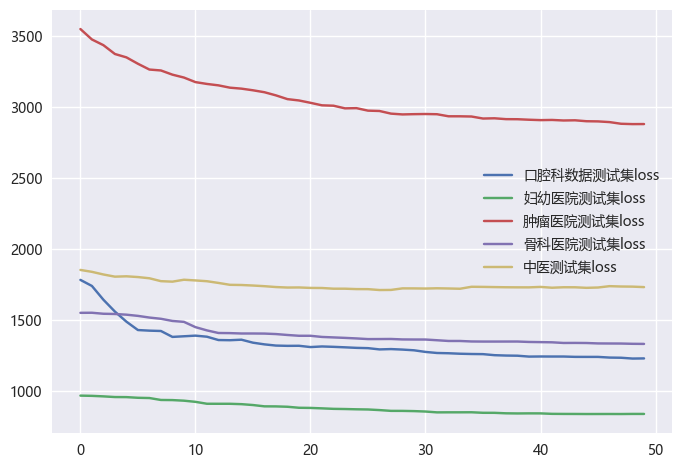

In [10]:
# for index in range(len(train_loss)):
#     valid_loss[index] = (valid_loss[index] + train_loss[index])/2
loss_dict = {
#     "全量数据训练集loss": train_loss,
#     "全量数据测试集loss": all_haocai_valid_loss,
#     "全量数(医院类别)据测试集loss":valid_loss1
#     "全量(ICU)数据训练集loss": is_icu_train_loss,
#     "全量(ICU)数据测试集loss": is_icu_valid_loss,
#     "全量(KS)数据训练集loss": ks_icu_train_loss,
#     "全量(KS)数据测试集loss": ks_icu_valid_loss,
#     "口腔科数据训练集loss": kq_valid_loss,
    "口腔科数据测试集loss": kq_haocai_valid_loss, 
#     "其他医院测试集loss": haocai_valid_loss,
    "妇幼医院测试集loss": fy_haocai_valid_loss,
    "肿瘤医院测试集loss": zn_haocai_valid_loss,
    "骨科医院测试集loss": gk_haocai_valid_loss,
    "中医测试集loss": zy_haocai_valid_loss,
#     "全量数据(医院类别)训练集loss": all_haocai_type_train_loss,
#     "全量数据(医院类别)测试集loss": all_haocai_type_valid_loss
#     "训练集loss": train_loss,
#     "测试集loss": valid_loss,
}
loss_df = pd.DataFrame(loss_dict)
loss_df.plot()

In [27]:
def internet_fee_predict(gbm, data_df):
    feature_list = ['age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4', "疾病_%s_mean" % '总费用',          
                 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3']
    
    x_train = data_df[feature_list]
    return gbm.predict(x_train)
df_train['predict'] = internet_fee_predict(gbm, df_train)
df_valid['predict'] = internet_fee_predict(gbm, df_valid)

In [28]:
df_train['总费用'] = df_train['总费用']/50
df_valid['总费用'] = df_valid['总费用']/50
df_train['OE'] = df_train['总费用']/df_train['predict']
df_valid['OE'] = df_valid['总费用']/df_valid['predict']

<AxesSubplot:>

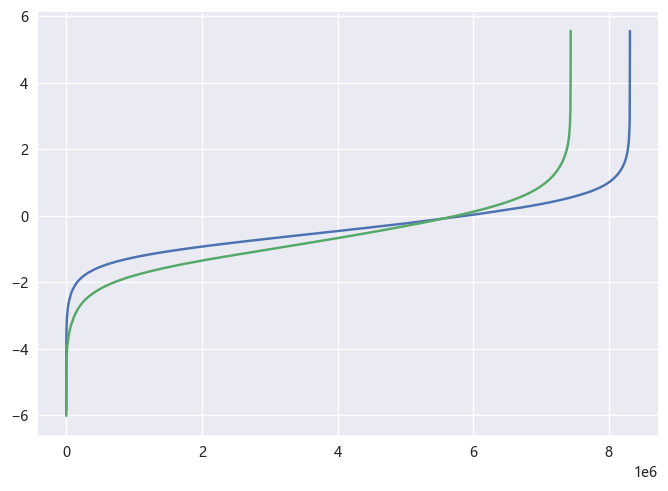

In [32]:
import math
df_train['LOG_OE'] = df_train['OE'].map(lambda a: math.log(a))
df_valid['LOG_OE'] = df_valid['OE'].map(lambda a: math.log(a))
df_valid['OE'].mean(), df_train['OE'].mean()
df_train['LOG_OE'].plot()
df_valid['LOG_OE'].plot()

In [40]:
df_valid['OE'].mean(), df_train['OE'].mean()

(0.8500571285306083, 0.9219937146424138)

<AxesSubplot:>

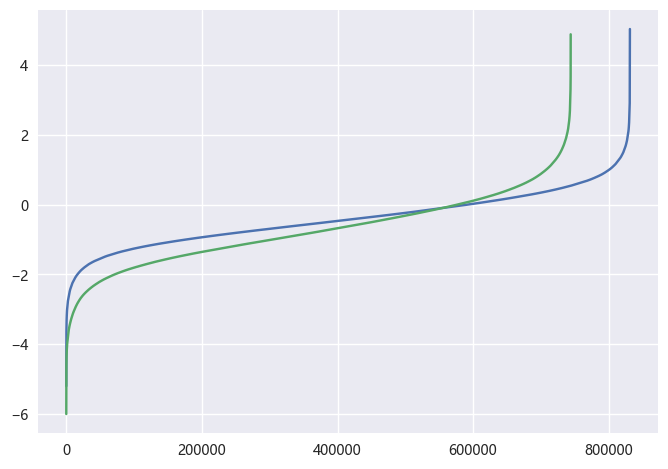

In [38]:
df_train_sample = df_train.sample(frac=0.1)
df_valid_sample = df_valid.sample(frac=0.1)
df_train_sample = df_train_sample.sort_values(by='OE').reset_index()
df_valid_sample = df_valid_sample.sort_values(by='OE').reset_index()
df_train_sample['LOG_OE'].plot()
df_valid_sample['LOG_OE'].plot()

In [39]:
df_train_sample.shape, df_valid_sample.shape

((831237, 17), (743890, 17))

In [34]:
df_valid.shape

(7438905, 16)

<AxesSubplot:>

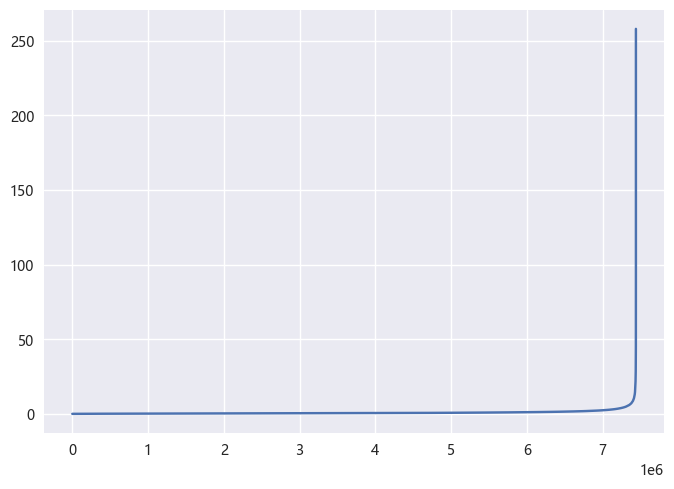

In [29]:
df_valid = df_valid.sort_values(by='OE').reset_index()
df_train = df_train.sort_values(by='OE').reset_index()
df_valid['OE'].plot()

In [57]:
def predict_all_haocai(gbm):
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '耗材费',
                "疾病_手术_%s_mean" % '耗材费',"疾病_%s_mean" % '耗材费',"手术_%s_mean" % '耗材费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 
                'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4', 'hos_type_encode']
    
    x_valid = df_valid[feature_list]
    return gbm.predict(x_valid)

# df_valid['all_hos_type_predict'] = predict_all_haocai(all_haocai_type_gbm)
# df_valid["OE"] = df_valid['耗材费']/df_valid['all_hos_type_predict']
# print(df_valid["OE"].mean())

# # no_ks_predict#
# df_valid["OE"] = df_valid['耗材费']/df_valid['no_ks_predict']
# print(df_valid["OE"].mean())

In [58]:
def predict_haocai_1(gbm):
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '耗材费',
                "疾病_手术_%s_mean" % '耗材费',"疾病_%s_mean" % '耗材费',"手术_%s_mean" % '耗材费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 
                'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    
    x_valid = df_train[feature_list]
    return gbm.predict(x_valid)
# df_train['no_ks_predict'] = predict_haocai_1(gbm)
# df_train['OE'] = df_train['no_ks_predict']/df_train['耗材费']
# df_train['OE'].mean()

In [ ]:
df_valid['all_hos_type_predict'] = predict_all_haocai(all_haocai_type_gbm)
df_valid["OE"] = df_valid['耗材费']/df_valid['all_hos_type_predict']

In [11]:
# df_train['医院类型'].unique()
# df_valid['no_ks_predict']

# haocai_gbm, haocai_train_loss, haocai_valid_loss = train_haocai(hos_type='其他')
# fy_haocai_gbm, fy_haocai_train_loss, fy_haocai_valid_loss = train_haocai(hos_type='妇幼')
# kq_haocai_gbm, kq_haocai_train_loss, kq_haocai_valid_loss = train_haocai(hos_type='口腔')
# zn_haocai_gbm, zn_haocai_train_loss, zn_haocai_valid_loss = train_haocai(hos_type='肿瘤')
# gk_haocai_gbm, gk_haocai_train_loss, gk_haocai_valid_loss = train_haocai(hos_type='骨科')
def predict_haocai(gbm):
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '检查检验费',
                "疾病_手术_%s_mean" % '检查检验费',"疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 
                'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    
    x_valid = df_valid[feature_list]
    return gbm.predict(x_valid)

# df_valid['no_ks_predict'] = predict_haocai(gbm)
df_valid['其他_precict'] = predict_haocai(haocai_gbm)
df_valid['妇幼_precict'] = predict_haocai(fy_haocai_gbm)
df_valid['口腔_precict'] = predict_haocai(kq_haocai_gbm)
df_valid['肿瘤_precict'] = predict_haocai(zn_haocai_gbm)
df_valid['骨科_precict'] = predict_haocai(gk_haocai_gbm)
df_valid['中医_precict'] = predict_haocai(zy_haocai_gbm)
df_valid['no_ks_predict'] = predict_haocai(all_haocai_gbm)



oe_result_dict = {}

fee_type = "检查检验费"

other_df = df_valid[df_valid['医院类型']=='其他']
other_df['other_OE'] = other_df['其他_precict']/other_df[fee_type] # all_hos_type_predict 其他_precict
other_df['OE'] = other_df['no_ks_predict']/other_df[fee_type]

oe_result_dict['其他模型-其他数据平均OE'] = [other_df['other_OE'].mean()]
oe_result_dict['全量模型-其他数据平均OE'] = [other_df['OE'].mean()]

other_df = df_valid[df_valid['医院类型']=='妇幼']
other_df['other_OE'] = other_df['妇幼_precict']/other_df[fee_type]# all_hos_type_predict 妇幼_precict
other_df['OE'] = other_df['no_ks_predict']/other_df[fee_type]

oe_result_dict['妇幼模型-妇幼数据平均OE'] = [other_df['other_OE'].mean()]
oe_result_dict['全量模型-妇幼数据平均OE'] = [other_df['OE'].mean()]

other_df = df_valid[df_valid['医院类型']=='口腔']
other_df['other_OE'] = other_df['口腔_precict']/other_df[fee_type] # all_hos_type_predict 口腔_precict
other_df['OE'] = other_df['no_ks_predict']/other_df[fee_type]

oe_result_dict['口腔模型-口腔数据平均OE'] = [other_df['other_OE'].mean()]
oe_result_dict['全量模型-口腔数据平均OE'] = [other_df['OE'].mean()]

other_df = df_valid[df_valid['医院类型']=='肿瘤']
other_df['other_OE'] = other_df['肿瘤_precict']/other_df[fee_type] # all_hos_type_predict 肿瘤_precict
other_df['OE'] = other_df['no_ks_predict']/other_df[fee_type]

oe_result_dict['肿瘤模型-肿瘤数据平均OE'] = [other_df['other_OE'].mean()]
oe_result_dict['全量模型-肿瘤数据平均OE'] = [other_df['OE'].mean()]

other_df = df_valid[df_valid['医院类型']=='骨科']
other_df['other_OE'] = other_df['骨科_precict']/other_df[fee_type] # all_hos_type_predict 骨科_precict
other_df['OE'] = other_df['no_ks_predict']/other_df[fee_type]

oe_result_dict['骨科模型-骨科数据平均OE'] = [other_df['other_OE'].mean()]
oe_result_dict['全量模型-骨科数据平均OE'] = [other_df['OE'].mean()]

other_df = df_valid[df_valid['医院类型']=='中医']
other_df['other_OE'] = other_df['中医_precict']/other_df[fee_type] # all_hos_type_predict 骨科_precict
other_df['OE'] = other_df['no_ks_predict']/other_df[fee_type]

oe_result_dict['中医模型-中医数据平均OE'] = [other_df['other_OE'].mean()]
oe_result_dict['全量模型-中医数据平均OE'] = [other_df['OE'].mean()]

pd.DataFrame(oe_result_dict).T.to_csv("检查检验费_OEV3.csv")
# df_valid['merge_hos_predict'] = df_valid.apply(lambda a: a["%s_predict" % a['医院类型']], axis=1)

# df_valid["OE_MERGE"] = df_valid['merge_hos_predict']/


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1472912\1683974480.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_df['other_OE'] = other_df['其他_precict']/other_df[fee_type] # all_hos_type_predict 其他_precict
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1472912\1683974480.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_df['OE'] = other_df['no_ks_predict']/other_df[fee_type]
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1472912\1683974480.py:42: SettingWithCopyWarn

In [143]:
other_df['OE'] = df_valid['no_ks_predict']/df_valid['耗材费']
print(other_df['OE'].mean())

3.736350992636876


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1784756\3583711536.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_df['OE'] = df_valid['no_ks_predict']/df_valid['耗材费']


In [13]:


haocai_result_dict = {
    "全量模型-其他数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='其他']['检查检验费'], df_valid[df_valid['医院类型']=='其他']['no_ks_predict'])**0.5],
    "其他模型-其他数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='其他']['检查检验费'], df_valid[df_valid['医院类型']=='其他']['其他_precict'])**0.5],
    
    "全量模型-妇幼数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='妇幼']['检查检验费'], df_valid[df_valid['医院类型']=='妇幼']['no_ks_predict'])**0.5],
    "其他模型-妇幼数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='妇幼']['检查检验费'], df_valid[df_valid['医院类型']=='妇幼']['妇幼_precict'])**0.5],
    
    "全量模型-口腔数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='口腔']['检查检验费'], df_valid[df_valid['医院类型']=='口腔']['no_ks_predict'])**0.5],
    "口腔模型-口腔数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='口腔']['检查检验费'], df_valid[df_valid['医院类型']=='口腔']['口腔_precict'])**0.5],
    
    "全量模型-肿瘤数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='肿瘤']['检查检验费'], df_valid[df_valid['医院类型']=='肿瘤']['no_ks_predict'])**0.5],
    "肿瘤模型-肿瘤数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='肿瘤']['检查检验费'], df_valid[df_valid['医院类型']=='肿瘤']['肿瘤_precict'])**0.5],
    
    "全量模型-骨科数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='骨科']['检查检验费'], df_valid[df_valid['医院类型']=='骨科']['no_ks_predict'])**0.5],
    "骨科模型-骨科数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='骨科']['检查检验费'], df_valid[df_valid['医院类型']=='骨科']['骨科_precict'])**0.5],       
    
    "全量模型-中医数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='中医']['检查检验费'], df_valid[df_valid['医院类型']=='中医']['no_ks_predict'])**0.5],
    "中医模型-中医数据集": [mean_squared_error(df_valid[df_valid['医院类型']=='中医']['检查检验费'], df_valid[df_valid['医院类型']=='中医']['中医_precict'])**0.5],
}
pd.DataFrame(haocai_result_dict).T.to_csv("LOSS_PIC_T_V3（检查检验费）.csv")

In [61]:
hos_type_num_df = df_valid.groupby('医院类型').size().to_frame().reset_index().rename(columns={0: "count"})
hos_type_num_df.to_csv("医院类型_timeV2.csv")

In [164]:
df_train.shape

(962714, 30)

In [10]:
def predict_only_ICU(gbm):
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '耗材费',
                "疾病_手术_%s_mean" % '耗材费', "疾病_%s_mean" % '耗材费',"手术_%s_mean" % '耗材费',          
                'basy_zyts', 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    x_valid = df_valid[feature_list]
    return gbm.predict(x_valid)
     
def predict(gbm):
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '检查检验费',
                "疾病_手术_%s_mean" % '检查检验费',"疾病_%s_mean" % '检查检验费',"手术_%s_mean" % '检查检验费',
                'basy_zyts', 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    x_valid = df_valid[feature_list]
    return gbm.predict(x_valid)

def predict_is_icu(gbm):
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '耗材费',
                "疾病_手术_%s_mean" % '耗材费',"疾病_%s_mean" % '耗材费',"手术_%s_mean" % '耗材费',
                'basy_zyts', 'IS_RY_KQ', 'IS_CY_KQ', 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    x_valid = df_valid[feature_list]
    return gbm.predict(x_valid)

def predict_ks(gbm):
    feature_list = ['basy_yydj','age','basy_xb','basy_zyzd_jbbm_3', 'basy_zyzd_jbbm_4','basy_zyzd_jbbm_5',
                'basy_zyzd_jbbm_6','basy_ssjczbm1_3', 'basy_ssjczbm1_4', 'basy_ssjczbm1_5', "年龄_医院级别_疾病_手术_%s_mean" % '耗材费',
                "疾病_手术_%s_mean" % '耗材费',"疾病_%s_mean" % '耗材费',"手术_%s_mean" % '耗材费',
                'basy_zyts', 'basy_rykb_encode', 'basy_cykb_encode', 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2', 'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4']
    x_valid = df_valid[feature_list]
    return gbm.predict(x_valid)


df_valid['no_ks_predict'] = predict(gbm) # 全量数据没有科室信息
# df_valid['is_icu'] = predict_is_icu(is_icu_gbm) # 全量数据有是否ICU信息
# df_valid['ks_predict'] = predict_ks(ks_icu_gbm) # 全量数据有KS类别信息
# df_valid['just_icu_predict'] = predict_only_ICU(only_icu_gbm) # 只用ICU数据训练

# df_valid['merge_just_icu_predict'] = df_valid.apply(lambda a: a['just_icu_predict'] if a['IS_RY_KQ']==1 else a['no_ks_predict'], axis=1)


In [14]:
df_valid['basy_yydj']

0          7
1          7
2          7
3          7
4          7
          ..
1849299    6
1849300    6
1849301    6
1849302    6
1849303    6
Name: basy_yydj, Length: 1849304, dtype: int64

In [14]:
df_valid['OE'] = df_valid['检查检验费']/df_valid['no_ks_predict']
# df_valid.groupby(['basy_caption']).agg({"OE": "mean"}).reset_index().to_csv("hos_mean_oe_jcjy.csv")
def hos_classification(a):
    if "肿瘤" in a:
        return "肿瘤"
    elif "骨科" in a:
        return "骨科"
    elif "口腔" in a:
        return "口腔"
    elif "妇幼" in a:
        return "妇幼"
    elif "中医" in a:
        return "中医"
    else:
        return "其他"
df_valid['医院类型'] = df_valid['basy_caption'].map(lambda a: hos_classification(a))
df_valid.groupby(['医院类型']).agg({"OE": "mean"}).reset_index().to_csv("医院类型_mean_oe_jcjy.csv")
# df_valid.groupby(['basy_yydj', '医院类型']).agg({"耗材费": "mean"}).reset_index().to_csv("医院等级_类型_fee_hc.csv")
# print(df_valid['OE'].mean())
df_train['医院类型'] = df_train['basy_caption'].map(lambda a: hos_classification(a))

# df_valid.groupby(['basy_caption']).agg({'检查检验费': "mean"}).reset_index().to_csv("医院_检查检验均值.csv")

def jb_lev_lx_mean():
    result_df = pd.DataFrame()
    for year_month in tqdm(['202402', '202403', '202404', '202405', '202406', '202407', '202408']):
        kb_jb_zd_df = pd.read_csv(project_root_path + "data/cleaned/cleaned_%s.csv" % year_month, 
                         usecols=['basy_zyzd_jbbm', '检查检验费', 'basy_caption', 'basy_yydj'])
#         kb_jb_zd_df = kb_jb_zd_df[kb_jb_zd_df['耗材费']>200]
        kb_jb_zd_df = kb_jb_zd_df[~pd.isna(kb_jb_zd_df['basy_zyzd_jbbm'])]
        kb_jb_zd_df['basy_zyzd_jbbm'] = kb_jb_zd_df['basy_zyzd_jbbm'].map(lambda a: disease_dict.get(a[:3], '空'))
        kb_jb_zd_df['医院类型'] = kb_jb_zd_df['basy_caption'].map(lambda a: hos_classification(a))                                                           
        result_df = pd.concat([result_df, kb_jb_zd_df])
    result_df['count'] = 1   
    group_jb_lev_lx_mean_df = result_df.groupby(['医院类型', 'basy_zyzd_jbbm', 'basy_yydj']).agg({'检查检验费': 'mean', "count": "sum"}).reset_index()
    return group_jb_lev_lx_mean_df

# group_jb_lev_lx_mean_df = jb_lev_lx_mean()

In [114]:
for hos_yydj in group_jb_lev_lx_mean_df['basy_yydj'].unique():
    hos_yydj_df = group_jb_lev_lx_mean_df[group_jb_lev_lx_mean_df['basy_yydj']==hos_yydj]
    result_df = None
    for name, group in hos_yydj_df.groupby('医院类型'):
        
#         print(hos_yydj, name)
        group_df = group.reset_index().rename(columns={"检查检验费": "检查检验费%s_%s" % (hos_yydj, name)})
        group_df = group_df[group_df["count"] > 20]
        group_df = group_df[['basy_zyzd_jbbm', "耗材费_%s_%s" % (hos_yydj, name)]]
        if result_df is None:
            result_df = group_df
        else:
            result_df = pd.merge(left=result_df, right=group_df, on='basy_zyzd_jbbm')
    result_df.to_csv("%s.csv" % hos_yydj)


全量数据没有科室训练模型，全体测试集LOSS信息 8266.309528316706
全量数据有KS类别信息训练模型，全体测试集LOSS信息 8268.10010035733


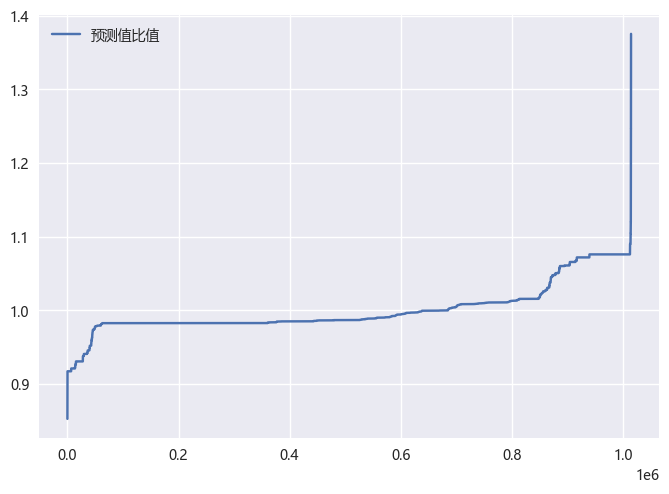

In [78]:
# icu_df_valid = df_valid[df_valid['IS_RY_KQ']==1]
# icu_df_valid['全量数据模型LOSS'] = icu_df_valid.apply(lambda a: abs(a['检查检验费'] - a['no_ks_predict']), axis=1)
# icu_df_valid['ICU数据模型LOSS'] = icu_df_valid.apply(lambda a: abs(a['检查检验费'] - a['just_icu_predict']), axis=1)
# icu_df_valid[['no_ks_predict', 'just_icu_predict', '检查检验费', '全量数据模型LOSS', 'ICU数据模型LOSS']]
df_valid["预测值比值"] = df_valid['ks_predict']/df_valid['no_ks_predict']
# icu_df_valid["预测值比值2"] = icu_df_valid['ks_predict']/icu_df_valid['检查检验费']
# icu_df_valid["预测值比值3"] = icu_df_valid['just_icu_predict']/icu_df_valid['检查检验费']


df_valid = df_valid.sort_values(by='预测值比值').reset_index()

df_valid[['预测值比值']].plot()

# print("全量数据没有科室训练模型，ICU测试集LOSS信息", mean_squared_error(icu_df_valid['耗材费'], icu_df_valid['no_ks_predict'])**0.5)
# print("全量数据有是否ICU信息训练模型，ICU测试集LOSS信息", mean_squared_error(icu_df_valid['检查检验费'], icu_df_valid['is_icu'])**0.5)
# print("全量数据有KS类别信息训练模型，ICU测试集LOSS信息", mean_squared_error(icu_df_valid['检查检验费'], icu_df_valid['ks_predict'])**0.5)
# print("只用ICU数据训练训练模型，ICU测试集LOSS信息", mean_squared_error(icu_df_valid['耗材费'], icu_df_valid['ks_predict'])**0.5)

print("全量数据没有科室训练模型，全体测试集LOSS信息", mean_squared_error(df_valid['耗材费'], df_valid['no_ks_predict'])**0.5)
# print("全量数据有是否ICU信息训练模型，全体测试集LOSS信息", mean_squared_error(df_valid['检查检验费'], df_valid['is_icu'])**0.5)
print("全量数据有KS类别信息训练模型，全体测试集LOSS信息", mean_squared_error(df_valid['耗材费'], df_valid['ks_predict'])**0.5)
# print("只用ICU数据训练训练模型，全体测试集LOSS信息", mean_squared_error(df_valid['检查检验费'], df_valid['merge_just_icu_predict'])**0.5)

# total_loss_list = icu_df_valid['全量数据模型LOSS'].tolist()
# icu_loss_list = icu_df_valid['ICU数据模型LOSS'].tolist()
# total_loss_list.sort()
# icu_loss_list.sort()
# pd.DataFrame({
#     "全量数据模型LOSS": total_loss_list,
#     "ICU数据模型LOSS": icu_loss_list,
    
# }).plot()

In [15]:

# df_valid.columns.tolist()

yydj_dict_V1 = {1: '二级未评等', 2: '二级乙等', 3: '二级甲等', 4: '三级未评等', 5: '三级乙等', 
             6: '三级甲等', 7: '未评级未评等', 8: '一级甲等', 9: '一级乙等', 10: "一级未评等"}
df_valid['basy_yydj_str'] = df_valid['basy_yydj'].map(lambda a: yydj_dict_V1[a])
df_valid.groupby(['basy_yydj_str', '医院类型']).agg({"检查检验费": "mean"}).reset_index().to_csv("医院类型等级检查检验费平均费用.csv") # , 'basy_zyzd_jbbm_3'
# df_valid.groupby(['basy_yydj_str']).agg({"检查检验费": "mean"}).reset_index().to_csv("医院等级-检查检验费.csv")

In [29]:
df_valid['检查检验费_mean'].isna().sum()/df_valid.shape[0]

0.058293822973399724

In [87]:
df_valid['OE'] = df_valid['检查检验费']/df_valid['no_ks_predict']

In [61]:
ks_dict

{32: '医学影像科',
 50: '中医科',
 52: '中西医结合科',
 30: '医学检验科',
 15: '精神科',
 24: '临终关怀科',
 5: '妇产科',
 16: '传染科',
 7: '儿科',
 9: '儿童保健科',
 3: '内科',
 2: '全科医疗科',
 69: '其他业务科室',
 14: '医疗美容科',
 12: '口腔科',
 11: '耳鼻咽喉科',
 4: '外科',
 6: '妇女保健科',
 8: '小儿外科',
 23: '职业病科',
 21: '康复医学科',
 20: '急诊医学科',
 51: '民族医学科',
 25: '特种医学与军事医学科',
 27: '疼痛科',
 31: '病理科',
 13: '皮肤科',
 10: '眼科',
 17: '结核病科',
 19: '肿瘤科',
 22: '运动医学科',
 28: '重症医学科',
 1: '预防保健科'}

In [14]:
valid_df = valid_df.sort_values('耗材费').reset_index()
def haocai_fee_claa(fee):
    if fee < 30:
        return "[0,30)"
    elif fee < 100:
        return "[30, 100)"
    elif fee < 500:
        return "[100, 500)"
    elif fee < 1000:
        return "[500, 1000)"
    elif fee < 3000:
        return "[1000, 3000)"
    elif fee < 10000:
        return "[3000, 10000)"
    elif fee > 10000:
        return "[10000, +++)"
valid_df['耗材费_区间']  = valid_df['耗材费'].map(lambda a: haocai_fee_claa(a))

valid_df['耗材费_区间'].value_counts().to_frame().reset_index().to_csv("耗材费_区间.csv")

In [40]:
kb_fee_df = valid_df.groupby(['basy_rykb', '耗材费_区间']).size().reset_index().rename(columns={0: '科别_费用区间人次'})
kb_df = valid_df.groupby('basy_rykb').size().reset_index()#.rename({'0': '科别人次'})
kb_df = kb_df[['basy_rykb', 0]]
kb_df = kb_df.rename(columns={0: '科别总人次'})
kb_fee_df = pd.merge(left=kb_fee_df, right=kb_df, on='basy_rykb', how='left')
kb_fee_df = kb_fee_df.rename(columns={"basy_rykb": "科室编号"})
kb_fee_df = pd.merge(left=kb_fee_df, right=kb_name_df, on='科室编号', how='left')
kb_fee_df.to_csv("费用区间人次占比.csv")

In [45]:
mean_fee_kb_df = valid_df.groupby('basy_rykb').agg({"耗材费": "mean"}).reset_index().rename(columns={"basy_rykb": '科室编号', '耗材费': "科室平均耗材费"})
mean_fee_kb_df = pd.merge(left=mean_fee_kb_df, right=kb_name_df, on='科室编号', how='left')
mean_fee_kb_df.to_csv("科室平均耗材费.csv")

In [22]:
diff_haocai_fee_df = valid_df[valid_df['耗材费']>10000]
# diff_haocai_fee_df = diff_haocai_fee_df[diff_haocai_fee_df['耗材费']<10000]
kb_df = diff_haocai_fee_df['basy_rykb'].value_counts().to_frame().reset_index()
kb_df = kb_df.rename(columns={"index": '科室编号', 'basy_rykb': '入院人次'})
kb_name_df = pd.read_excel('D:/yuanjun/SuperviserProject/docs/临床学科字典.xlsx')
kb_name_df = kb_name_df.rename(columns={'discipline_id':'科室编号', 'discipline_name': '科室名称'})
kb_name_df = kb_name_df[['科室编号', '科室名称']]
kb_name_df = kb_name_df.drop_duplicates(subset=['科室编号'])
print(kb_df.shape)
kb_df = pd.merge(left=kb_df, right=kb_name_df, on='科室编号', how='left')
print(kb_df.shape)
kb_df.to_csv('入院人次占比(耗材费大于10000).csv')

(30, 2)
(30, 3)


In [91]:
valid_df['出入院科别一致占比']  = valid_df.apply(lambda a: 1 if a['basy_rykb']==a['basy_cykb'] else 0, axis=1)

C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_1196076\655950052.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['出入院科别一致占比']  = valid_df.apply(lambda a: 1 if a['basy_rykb']==a['basy_cykb'] else 0, axis=1)


In [96]:
# valid_df['出入院科别一致占比'].sum()/valid_df.shape[0]
kb_dict = {code:name for code, name in zip(kb_name_df['科室编号'].tolist(), kb_name_df['科室名称'].tolist())}
print(kb_dict)
not_match_kb_df = valid_df[valid_df['出入院科别一致占比']==0][['basy_rykb', 'basy_cykb']]
not_match_kb_df['入院科别名称'] = not_match_kb_df['basy_rykb'].map(lambda a: kb_dict.get(a, 'unname'))
not_match_kb_df['出院科别名称'] = not_match_kb_df['basy_cykb'].map(lambda a: kb_dict.get(a, 'unname'))
not_match_kb_df

{32: '医学影像科', 50: '中医科', 52: '中西医结合科', 30: '医学检验科', 15: '精神科', 24: '临终关怀科', 5: '妇产科', 16: '传染科', 7: '儿科', 9: '儿童保健科', 3: '内科', 2: '全科医疗科', 69: '其他业务科室', 14: '医疗美容科', 12: '口腔科', 11: '耳鼻咽喉科', 4: '外科', 6: '妇女保健科', 8: '小儿外科', 23: '职业病科', 21: '康复医学科', 20: '急诊医学科', 51: '民族医学科', 25: '特种医学与军事医学科', 27: '疼痛科', 31: '病理科', 13: '皮肤科', 10: '眼科', 17: '结核病科', 19: '肿瘤科', 22: '运动医学科', 28: '重症医学科', 1: '预防保健科'}


,basy_rykb,basy_cykb,入院科别名称,出院科别名称
1169,3,50,内科,中医科
1191,3,4,内科,外科
2620,3,4,内科,外科
2650,28,3,重症医学科,内科
2699,3,4,内科,外科
...,...,...,...,...
1958690,50,3,中医科,内科
1958711,50,3,中医科,内科
1958754,11,16,耳鼻咽喉科,传染科
1958767,3,16,内科,传染科


In [105]:
not_match_group = not_match_kb_df['入院科别名称'].value_counts().to_frame().reset_index().rename(columns={'index': '科室名称', '入院科别名称': '人次'})
not_match_group['人次占比'] = not_match_group['人次']/not_match_group['人次'].sum()
not_match_group.to_csv('不匹配入院科别.csv')

In [39]:
df_valid['predict'] = gbm.predict(df_valid[feature_list])
print(df_valid['predict'].min(), df_valid['predict'].max())
df_valid['OE'] = df_valid['检查检验费']/df_valid['predict']
print(df_valid['OE'].min(), df_valid['OE'].max())

159.29622334013715 34371.08501042871
0.0 81.41298913272169


In [57]:
def high_oe_ratio(predict_name):
    df_valid['basy_rykb_name'] = df_valid['basy_rykb'].map(lambda a: ks_dict.get(a, '空白'))
    df_valid['OE'] = df_valid['耗材费']/df_valid[predict_name]
    high_threshold_score = sorted(df_valid['OE'].tolist(), reverse=True)[int(df_valid.shape[0]/100)]
    df_valid['是否口腔科'] = df_valid['basy_rykb'].map(lambda a: "口腔科" if a==12 else "其他科室")
    df_valid['high_score'] = df_valid['OE'].map(lambda a: 1 if a>high_threshold_score else 0)
    df_valid.groupby(['是否口腔科', 'high_score']).size().to_frame().reset_index().rename(columns={'high_score': '高OE值', 0: '人次'}).to_csv("100高(M)OE_V2(耗材).csv")
    df_valid.groupby(['是否口腔科']).agg({"OE": "mean"}).reset_index()

    high_score_df = df_valid[df_valid['high_score']==1]
    low_score_df = df_valid[df_valid['high_score']==0]
    high_group = high_score_df.groupby('basy_rykb_name').size().to_frame().reset_index().rename(columns={"basy_rykb_name": "科室名称", 0: "高OE值人次(%s)" % predict_name})
    total_group = df_valid.groupby('basy_rykb_name').size().to_frame().reset_index().rename(columns={"basy_rykb_name": "科室名称", 0: "所有人次(%s)" % predict_name})
    high_group = pd.merge(left=high_group, right=total_group, on='科室名称', how='left')
    high_group['高OE值人次占比(%s)' % predict_name] = high_group["高OE值人次(%s)" % predict_name]/high_group["所有人次(%s)" % predict_name]
    high_group = high_group.sort_values(by='高OE值人次占比(%s)' % predict_name, ascending=False).reset_index()
#     high_group.to_csv('科室高OE值占比.csv')
    return high_group[['科室名称', '高OE值人次占比(%s)' % predict_name]]
    
ks_group_df = high_oe_ratio('no_ks_predict')
# only_icu_group_df = high_oe_ratio('merge_just_icu_predict')
# pd.merge(left=ks_group_df, right=only_icu_group_df, on='科室名称', how='left').to_csv("高OE值人次占比(耗材)V2.csv")

In [53]:
df_valid.groupby(['是否口腔科']).agg({"OE": "mean"}).reset_index()

,是否口腔科,OE
0,其他科室,0.938991
1,口腔科,1.374529


In [27]:
df_valid['KS_OE'] = df_valid['检查检验费']/df_valid['ks_predict']
df_valid['ONLY_ICU_OE'] = df_valid['检查检验费']/df_valid['merge_just_icu_predict']
ks_oe_df = df_valid.groupby('basy_rykb_name').agg({"KS_OE": "mean"}).reset_index()# .to_csv("ks_mean_oe_V1.csv")
only_icu_oe_df = df_valid.groupby('basy_rykb_name').agg({"ONLY_ICU_OE": "mean"}).reset_index()
pd.merge(left=ks_oe_df, right=only_icu_oe_df, on='basy_rykb_name', how='left').to_csv("oe_compare.csv")

In [82]:
df_valid['basy_zyts'].unique()

array([0], dtype=int64)

In [45]:
valid_df = valid_df.rename(columns={'basy_cykb': '科室编号'})
valid_df = pd.merge(left=valid_df, right=kb_name_df, on='basy_cykb', how='left')

,Unnamed: 0.1,temp_id,basy_sfzh_md5,basy_yljgid,basy_bah,basy_xb,basy_csrq,basy_rysj,basy_cysj,basy_cykb,...,basy_ssjczbm1_7,basy_zyzd_jbbm_8,basy_ssjczbm1_8,basy_zyzd_jbbm_9,basy_ssjczbm1_9,age,age_group,count,basy_zyts,OE
0,0,0,b9ba08766a64e6c553ce2eaa01bbd165,JG_510000007070,BAH_0904109120240626002,0,19510710,2024-06-26,2024-07-07,3,...,5240,5969,6080,6101,6091,73,8,1,0,2.500285
1,1,1,b1ecbfcf11b6c837fcefe4d1a4317362,JG_510000007070,BAH_0904109120240625003,0,19430814,2024-06-25,2024-07-03,3,...,5240,8268,6080,8452,6091,81,9,1,0,5.084087
2,2,2,baaf23a8e889fa52a596dc5f85baf4a2,JG_510000007070,BAH_0904109120240628006,0,19580811,2024-06-28,2024-07-05,3,...,5240,7621,6080,7797,6091,66,6,1,0,6.134201
3,3,3,12ca921e2d8536a37b2b47305b0a9adc,JG_510000007070,BAH_0904109120240623001,0,19620510,2024-06-23,2024-07-02,3,...,5240,5729,6080,5839,6091,62,6,1,0,1.859288
4,4,4,23c4aa9d33097a61528f8a3646700051,JG_510000007070,BAH_0904109120240628008,0,19631202,2024-06-28,2024-07-09,3,...,5240,8838,6080,9048,6091,61,6,1,0,5.042591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1958789,1958789,1958789,f59a16e62d536741c8038301a68150ca,JG_510000X66701,BAH_0000062252,0,19541008,2024-07-16,2024-07-23,4,...,2185,6657,2506,6815,2514,70,8,1,0,NaN
1958790,1958790,1958790,0112063944d6834e3b1a6b09defb2690,JG_510000X66701,BAH_0000061273,0,20160913,2024-06-27,2024-07-02,11,...,1221,5854,1401,5981,1404,8,0,1,0,NaN
1958791,1958791,1958791,b4243a8be6727e0729f6e4b76e31640f,JG_510000X66701,BAH_0000061492,0,19621218,2024-07-01,2024-07-19,50,...,768,3872,883,3949,883,62,6,1,0,NaN
1958792,1958792,1958792,a3995133a5102a33d9416f243d25f651,JG_510000X66701,BAH_0000061405,0,19590207,2024-06-30,2024-07-05,3,...,760,5966,875,6097,875,65,6,1,0,NaN


In [21]:
def get_map_score(score, cut_list):
    cut_list_len = len(cut_list)
    left = 0
    right = len(cut_list)
    mid = int((left + right)/2)
    while mid > 0 and mid < cut_list_len-1:
        if score == cut_list[mid]:
            return mid/cut_list_len
        elif (score < cut_list[mid]) and (score > cut_list[mid-1]):
            return mid/cut_list_len
        elif (score > cut_list[mid]) and (score < cut_list[mid+1]):
            return (mid+1)/cut_list_len
        elif score < cut_list[mid]:
            right = mid-1
        elif score > cut_list[mid]:
            left = mid+1
        mid = int((left + right)/2)

    if mid == 0:
        return 1/cut_list_len
    else:
        return 1 - 1/cut_list_len
# cut_list = [i for i in range(1000)]
print(get_map_score(0.90, result_cut_list))

0.999


In [19]:
result_cut_list

[0,
 0.015611074435822,
 0.0188442877355782,
 0.0206990994580993,
 0.0225384718846294,
 0.024855351442652,
 0.0268316853560602,
 0.0286848599710789,
 0.0308209586561686,
 0.032908377538994,
 0.0346817560680705,
 0.036130866080241,
 0.038008708694932,
 0.0395466637018678,
 0.0414092281009434,
 0.0432430430648496,
 0.0451345777234172,
 0.0468383083182841,
 0.0485875497461735,
 0.0502152926823262,
 0.0516684304262828,
 0.0528338205919658,
 0.0543452939792598,
 0.0558063774927426,
 0.057149520344253,
 0.0585594363698259,
 0.0596778916792069,
 0.0607726245599241,
 0.0619058320788757,
 0.0631420690346655,
 0.0641630843179509,
 0.065090211164895,
 0.0660218803931638,
 0.0668754715943479,
 0.0677955027904381,
 0.0686939524689193,
 0.0697321196404284,
 0.0707711435352164,
 0.0718403550652796,
 0.0727191207219486,
 0.0737061317036456,
 0.0745031373531405,
 0.0754321584570031,
 0.0762578867228329,
 0.0771514448034477,
 0.0780860972523467,
 0.0789032430304012,
 0.0798162760590613,
 0.0806541458416

In [10]:
import pandas as pd
def get_cut_point(score_list):
    list_len = len(score_list)
    cut_list = [0]
    for i in range(1, 1000):
        if i != 999:
            cut_list.append(score_list[int(i*list_len/999)])
        else:
            cut_list.append(1)
    return cut_list
# ccd_df = pd.read_csv("D:/yuanjun/data_2024/2015-2020-featureV1-5split/valid_0_eci_feature_V1(CCD)(heart-feature)(eigen).csv")
# print(ccd_df.columns.tolist())
TC_df = pd.read_csv("D:/yuanjun/data_2024/2015-2020-featureV1-5split/valid_0_disease_feature(TC).csv")
print(TC_df.columns.tolist())

['Unnamed: 0.4', 'Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'basy_sfzh_md5', '生日', '性别', '民族', '职业', '婚姻状况', '医保类型', '城镇VS农村', '住址', '药物过敏情况', '既往住院次数', '既往总住院时间', '既往平均住院时间', '既往总费用', '既往平均费用', '既往平均住院间隔时长', '既往手术类别+00', '既往手术类别+01', '既往手术类别+02', '既往手术类别+03', '既往手术类别+04', '既往手术类别+05', '既往手术类别+06', '既往手术类别+07', '既往手术类别+08', '既往手术类别+09', '既往手术类别+10', '既往手术类别+11', '既往手术类别+12', '既往手术类别+13', '既往手术类别+14', '既往手术类别+15', '既往手术类别+16', '既往手术类别+17', '既往手术类别+18', '既往手术类别+19', '既往手术类别+20', '既往手术类别+21', '既往手术类别+22', '既往手术类别+23', '既往手术类别+24', '既往手术类别+25', '既往手术类别+26', '既往手术类别+27', '既往手术类别+28', '既往手术类别+29', '既往手术类别+30', '既往手术类别+31', '既往手术类别+32', '既往手术类别+33', '既往手术类别+34', '既往手术类别+35', '既往手术类别+36', '既往手术类别+37', '既往手术类别+38', '既往手术类别+39', '既往手术类别+40', '既往手术类别+41', '既往手术类别+42', '既往手术类别+43', '既往手术类别+44', '既往手术类别+45', '既往手术类别+46', '既往手术类别+47', '既往手术类别+48', '既往手术类别+49', '既往手术类别+50', '既往手术类别+51', '既往手术类别+52', '既往手术类别+53', '既往手术类别+54', '既往手术类别+55', '既往手术类别+56', '既往手术类别+57', '既往手术类别+58', '既往手术

In [11]:
import json

# print(ccd_df['predict'])
ccd_predict_list = TC_df['predict'].tolist()
ccd_predict_list.sort()
result_cut_list = get_cut_point(ccd_predict_list)
print(len(result_cut_list))

print(ccd_predict_list[:5], ccd_predict_list[-5:])
json_str = json.dumps(result_cut_list)

save_path = 'D:/yuanjun/SunProject_online/SunProject_online/SunProject/online_model/'
# 将 JSON 字符串写入文件
with open(save_path + 'TC_cut_list.json', 'w') as f:
    f.write(json_str)

1000
[0.0032377995324907, 0.0041982872816133, 0.0042239028080265, 0.0042421937764741, 0.0047568675936496] [0.9244814253202712, 0.9253259789191935, 0.928576506037302, 0.9304047319425331, 0.9464609668817132]


In [26]:
diseases_dict = {
    'zj_01': ['I25', 'T82', 'Z95'],                              # 冠心病
    'zj_02': ['I60', 'I61', 'I62', 'I63', 'I64', 'I69'],         # 脑卒中
    'zj_03': ['N17', 'N18', 'N19'],                              # 尿毒症
    'zj_04': ['I21', 'T82', 'Z95'],                              # 急性心肌梗塞
    'zj_05': ['C50'],                                            # 乳房恶性肿瘤
    'zj_06': ['C34'],                                            # 支气管和肺恶性肿瘤
    'zj_07': ['C17', 'C18', 'C19', 'C20'],                       # 肠恶性肿瘤
    'zj_08': ['C73'],                                            # 甲状腺恶性肿瘤
    'zj_09': ['I09', 'I05', 'I06', 'I07', 'I08'],                # 风湿性心脏病
    'zj_10': ['C22'],                                            # 肝和肝内胆管恶性肿瘤
    'zj_11': ['C16'],                                            # 胃恶性肿瘤
    'zj_12': ['C81', 'C82', 'C83', 'C84', 'C86', 'C88'],  # 淋巴瘤
    'zj_13': ['M32'],                                            # 系统性红斑狼疮
    'zj_14': ['C54', 'C55'],                                     # 子宫体及子宫未特指恶性肿瘤
    'zj_15': ['C95', 'C91', 'C92', 'C93', 'C94'],                # 白血病
    'zj_16': ['C64', 'C65'],                                     # 肾癌
    'zj_17': ['C61'],                                            # 前列腺癌
    'zj_18': ['C67'],                                            # 膀胱癌
    'zj_19': ['C53'],                                            # 宫颈恶性肿瘤
    'zj_20': ['C56'],                                            # 卵巢恶性肿瘤
    'zj_21': ['C15'],                                            # 食管恶性肿瘤
    'zj_22': ['C24', 'C23'],                                     # 胆囊及胆道的恶性肿瘤
    'zj_23': ['C25'],                                            # 胰腺癌
    'zj_24': ['C14', 'C10', 'C12', 'C13'],                       # 除鼻咽癌以外的咽癌
    'zj_25': ['C70', 'C71', 'C72'],                              # 脑及中枢神经系统恶性肿瘤
    'zj_26': ['C79', 'C77', 'C78', 'C80'],                       # 继发性恶性肿瘤
    'zj_27': ['C11'],                                            # 鼻咽癌
    'zj_28': ['41.0', '55.6', '50.5', '37.51', '33.5'],          # 重大器官移植术或造血干细胞移植术
    'zj_29': ['36.1', '88.55', '88.56', '88.57'],                # 心脏瓣膜手术
    'zj_30': ['C85', 'C94'],                                      # 淋巴肉瘤
    'zj_31': ['C40'],                                             # 四肢骨和关节软骨恶性肿瘤
    'zj_32': ['C97'],                                             # 独立(原发)多个部位的恶性肿瘤
    'zj_33': ['C31'],                                             # 鼻旁窦恶性肿瘤
    'zj_34': ['C37'],                                             # 胸腺恶性肿瘤
    'zj_35': ['C57'],                                             # 女性生殖器官其他和未特指的恶性肿瘤
    'zj_36': ['C49'],                                             # 其他结缔组织和软组织恶性肿瘤
    'zj_37': ['C90'],                                             # 多发性骨髓瘤和恶性浆细胞肿瘤
    'zj_38': ['C52'],                                             # 阴道恶性肿瘤
    'zj_39': ['C76'],                                             # 其他和不明确部位的恶性肿瘤
    'zj_40': ['C08'],                                             # 大涎腺其他和未特指的恶性肿瘤
}


diseases_cn_dict = {
    'zj_01': '冠心病',
    'zj_02': '脑卒中',
    'zj_03': '尿毒症',
    'zj_04': '急性心肌梗塞',
    'zj_05': '乳房恶性肿瘤',
    'zj_06': '支气管和肺恶性肿瘤',
    'zj_07': '肠恶性肿瘤',
    'zj_08': '甲状腺恶性肿瘤',
    'zj_09': '风湿性心脏病',
    'zj_10': '肝和肝内胆管恶性肿瘤',
    'zj_11': '胃恶性肿瘤',
    'zj_12': '淋巴瘤',
    'zj_13': '系统性红斑狼疮',
    'zj_14': '子宫体及子宫未特指恶性肿瘤',
    'zj_15': '白血病',
    'zj_16': '肾癌',
    'zj_17': '前列腺癌',
    'zj_18': '膀胱癌',
    'zj_19': '宫颈恶性肿瘤',
    'zj_20': '卵巢恶性肿瘤',
    'zj_21': '食管恶性肿瘤',
    'zj_22': '胆囊及胆道的恶性肿瘤',
    'zj_23': '胰腺癌',
    'zj_24': '除鼻咽癌以外的咽癌',
    'zj_25': '脑及中枢神经系统恶性肿瘤',
    'zj_26': '继发性恶性肿瘤',
    'zj_27': '鼻咽癌',
    'zj_28': '重大器官移植术或造血干细胞移植术',
    'zj_29': '心脏瓣膜手术',
    'zj_30': '淋巴肉瘤',
    'zj_31': '四肢骨和关节软骨恶性肿瘤',
    'zj_32': '独立(原发)多个部位的恶性肿瘤',
    'zj_33': '鼻旁窦恶性肿瘤',
    'zj_34': '胸腺恶性肿瘤',
    'zj_35': '女性生殖器官其他和未特指的恶性肿瘤',
    'zj_36': '其他结缔组织和软组织恶性肿瘤',
    'zj_37': '多发性骨髓瘤和恶性浆细胞肿瘤',
    'zj_38': '阴道恶性肿瘤',
    'zj_39': "其他和不明确部位的恶性肿瘤",
    'zj_40': "大涎腺其他和未特指的恶性肿瘤"
}

result_dict = {
    "重疾分类":[],
    "ICD-10编码":[],
}
for key,value in diseases_cn_dict.items():
    result_dict['重疾分类'].append(value)
    result_dict['ICD-10编码'].append(','.join(diseases_dict[key]))
pd.DataFrame(result_dict).to_csv("D:/yuanjun/SunProject_online/SunProject_online/SunProject/data/40_disease.csv")

In [23]:
# The Bitter Lesson
# Rich Sutton
# March 13, 2019
# The biggest lesson that can be read from 70 years of AI research is that general methods that leverage
# computation are ultimately the most effective, and by a large margin. The ultimate reason for this is
# Moore's law, or rather its generalization of continued exponentially falling cost per unit of
# computation. Most AI research has been conducted as if the computation available to the agent were
# constant (in which case leveraging human knowledge would be one of the only ways to improve
# performance) but, over a slightly longer time than a typical research project, massively more
# computation inevitably becomes available. Seeking an improvement that makes a difference in the
# shorter term, researchers seek to leverage their human knowledge of the domain, but the only thing
# that matters in the long run is the leveraging of computation. These two need not run counter to each
# other, but in practice they tend to. Time spent on one is time not spent on the other. There are
# psychological commitments to investment in one approach or the other. And the human-knowledge
# approach tends to complicate methods in ways that make them less suited to taking advantage of
# general methods leveraging computation.  There were many examples of AI researchers' belated
# learning of this bitter lesson, and it is instructive to review some of the most prominent.
import os
from tqdm import tqdm
root_path = "D:/data/origin_data/"
result_df = None
result_df1= None
for file_name in tqdm(os.listdir(root_path)):
    df = pd.read_csv(root_path+file_name, usecols=['basy_zfy', 'basy_cysj', 'basy_sfzh_md5'])
#     md5_df = df.drop_duplicates('basy_sfzh_md5')
    df['basy_cysj'] = df['basy_cysj'].map(lambda a: a[:4])
    df['count'] = 1
    tmp_result = df.groupby('basy_cysj').agg({'basy_zfy':'sum', 'count':'sum'}).reset_index()
    if result_df is None:
        result_df = tmp_result
    else:
        result_df = pd.concat([result_df, tmp_result])
        result_df = result_df.groupby('basy_cysj').agg({'basy_zfy':'sum', 'count': 'sum'}).reset_index()
    
    num_df = df.groupby('basy_cysj').basy_sfzh_md5.unique().to_frame().reset_index()
    num_df['basy_sfzh_md5'] = num_df['basy_sfzh_md5'].map(lambda a: len(a))
    num_df = num_df.rename(columns={'basy_sfzh_md5': '人数'})
    
    if result_df1 is None:
        result_df1 = num_df
    else:
        result_df1 = pd.concat([result_df1, num_df])
        result_df1 = result_df1.groupby('basy_cysj').agg({'人数': 'sum'}).reset_index()
    
    
result_df1

100%|████████████████████████████████████████████████████████████████████████████████| 105/105 [18:40<00:00, 10.68s/it]


,basy_cysj,人数
0,2015,5508545
1,2016,8535780
2,2017,8731947
3,2018,7309436
4,2019,12675237
5,2020,11366655
6,2021,11892142
7,2022,12088745
8,2023,14134638
9,2024,11884473


In [24]:
result_df1.to_csv("人数分布.csv")

In [51]:
result_df1

,basy_zyzd_jbbm,次数,次数小于100,次数小于50,次数小于20
0,"""""""""""""""""""""",2,1,1,1
1,#ERR,1,1,1,1
2,#ERR:#ERR:女性盆腔积液,1,1,1,1
3,#ERR:080.000,1,1,1,1
4,#ERR:39周宫内孕头位活胎临产,2,1,1,1
...,...,...,...,...,...
111384,Ｔ00.8,1,1,1,1
111385,Ｔ29.001,1,1,1,1
111386,Ｔ－区性淋巴瘤,1,1,1,1
111387,ｎ,1,1,1,1


In [58]:
result_df1["次数小于100"] = result_df1["次数"].map(lambda a: 1 if a<100 else 0)
result_df1["次数小于50"] = result_df1["次数"].map(lambda a: 1 if a<50 else 0)
result_df1["次数小于20"] = result_df1["次数"].map(lambda a: 1 if a<20 else 0)
result_df1["次数小于10"] = result_df1["次数"].map(lambda a: 1 if a<10 else 0)
print('主要疾病次数小于100次的住院次数占比：', result_df1[result_df1["次数小于100"]==1]['次数'].sum()/result_df1['次数'].sum())
print('主要疾病次数小于50次的住院次数占比：', result_df1[result_df1["次数小于50"]==1]['次数'].sum()/result_df1['次数'].sum())
print('主要疾病次数小于20次的住院次数占比：', result_df1[result_df1["次数小于20"]==1]['次数'].sum()/result_df1['次数'].sum())
print('主要疾病次数小于10次的住院次数占比：', result_df1[result_df1["次数小于10"]==1]['次数'].sum()/result_df1['次数'].sum())


主要疾病次数小于100次的住院次数占比： 0.006108937245290208
主要疾病次数小于50次的住院次数占比： 0.0035256406925003882
主要疾病次数小于20次的住院次数占比： 0.001725603570215152
主要疾病次数小于10次的住院次数占比： 0.0010106483886184825


In [20]:
result_df.to_csv("费用_人次分布.csv")

In [44]:
import os
from tqdm import tqdm
root_path = "D:/data/origin_data/"
result_df = pd.DataFrame()
result_df1 = pd.DataFrame()
for file_name in tqdm(os.listdir(root_path)):
    df = pd.read_csv(root_path+file_name, usecols=['basy_zyzd_jbbm'])
    df['jbbm_length'] = df['basy_zyzd_jbbm'].map(lambda a: len(a) if isinstance(a, str) else 0)
#     print(df.groupby('jbbm_length').size().reset_index().rename(columns={0: '次数'}))
    result_df = pd.concat([result_df, df.groupby('jbbm_length').size().reset_index().rename(columns={0: '次数'})])
    result_df = result_df.groupby('jbbm_length').agg({'次数': 'sum'}).reset_index()
#     print(result_df)
    result_df1 = pd.concat([result_df1, df.groupby('basy_zyzd_jbbm').size().reset_index().rename(columns={0: '次数'})])
    result_df1 = result_df1.groupby('basy_zyzd_jbbm').agg({'次数': 'sum'}).reset_index()
#     print("####")
#     print(result_df1)
#     break

100%|████████████████████████████████████████████████████████████████████████████████| 105/105 [16:12<00:00,  9.26s/it]


In [46]:
result_df.to_csv('编码长度.csv')

In [17]:
import os
import pandas as pd
from tqdm import tqdm
import numpy as np
root_path = "D:/data/origin_data/"
total_result_df = pd.DataFrame()


for file_name in tqdm(os.listdir(root_path)):
    df = pd.read_csv(root_path+file_name, usecols=['basy_zyzd_jbbm', 'basy_cysj', 'basy_zfy', 'basy_rysj', 'basy_sfzh_md5'])
    df['nian'] = df['basy_cysj'].map(lambda a: int(a[:4]) if isinstance(a, str) else '')
    df = df[df['nian'].isin([2023])]
    df['count'] = 1
    df[['basy_rysj', 'basy_cysj']] = df[['basy_rysj', 'basy_cysj']].astype('datetime64[ns]')
    df['住院天数'] = df['basy_cysj'] - df['basy_rysj']
    df['住院天数'] = df['住院天数'].map(lambda x: int(x / np.timedelta64(1, 'D')) if not pd.isna(x) else x)
    result_df1 = df.groupby(['basy_zyzd_jbbm']).agg({'basy_zfy': 'sum', '住院天数': 'sum', 'count': 'sum'}).reset_index()
    result_df1 = result_df1.rename(columns={'basy_zyzd_jbbm': '疾病编码', 'basy_zfy': '总费用', '住院天数': '总住院天数', 'count': '总住院次数'})
    result_df2 = df.groupby(['basy_zyzd_jbbm', 'basy_sfzh_md5']).agg({'count': 'sum'}).reset_index().reset_index()
    result_df2['总人数'] = 1
    result_df2 = result_df2.groupby('basy_zyzd_jbbm').agg({'总人数': 'sum'}).reset_index()
    result_df2 = result_df2.rename(columns={'basy_zyzd_jbbm': '疾病编码'})
    result_df = pd.merge(left=result_df1, right=result_df2, on='疾病编码')
#     print(result_df)
    
    total_result_df = pd.concat([total_result_df, result_df])
    total_result_df = total_result_df.groupby('疾病编码').agg({'总费用': 'sum', '总住院天数': 'sum', '总住院次数': 'sum', '总人数': 'sum'}).reset_index()
#     print(total_result_df)
    
#     total_result_df1 = pd.concat([total_result_df1, result_df1])
#     total_result_df1.groupby('疾病编码').agg({''})
    
    
#     break


100%|████████████████████████████████████████████████████████████████████████████████| 105/105 [26:17<00:00, 15.02s/it]


In [16]:
total_result_df.groupby('疾病编码').agg({'总费用': 'sum', '总住院天数': 'sum', '总住院次数': 'sum', '总人数': 'sum'}).reset_index()

,疾病编码,总费用,总住院天数,总住院次数,总人数
0,A00.000,7001.12,9,3,3
1,A00.100,512.52,7,2,2
2,A00.900,50176.13,73,11,10
3,A00.900x002,15528.66,26,4,3
4,A00.900x003,21856.73,7,2,2
...,...,...,...,...,...
32653,Z99.100,331626.61,514,2,2
32654,Z99.100x001,1188019.51,724,1,1
32655,Z99.200,10134.88,27,2,2
32656,Z99.200x002,7641.75,7,2,2


In [19]:
total_result_df.to_csv("疾病情况.csv")